In [5]:
%load_ext autoreload
%autoreload 2

In [1]:
import sys
sys.path.append('./')
sys.path.append('/Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/auton-survival/')

import pandas as pd
import numpy as np

import torch
from tqdm import tqdm 
from examples.cmhe_demo_utils import * 
from auton_survival import reporting
import matplotlib.pyplot as plt
from metrics import treatment_effect
from matplotlib.pyplot import figure

c:\Users\ASUS\anaconda3\envs\Pandas\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from datasets_retrospective import load_accord_dataset
outcomes, features, intervention, cat_feats, num_feats = load_accord_dataset(location='/Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/auton-survival/auton_survival/datasets/', outcome='', intervention='Lipid')

No Features Specified!! using default baseline features.
(10251, 5)
(10205, 3)
(10251, 18)
(10197, 5)
(10240, 9)


c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, col] = df[col].values.astype(str)
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:746: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outcomes['event'] = 1-outcomes['event']
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_re

In [3]:
outcomes.time = outcomes.time / 365.25

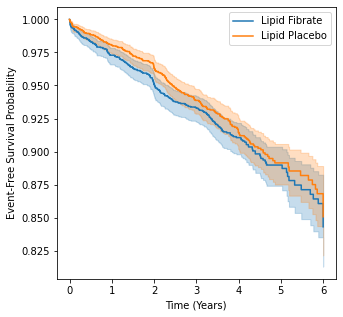

In [4]:
# Let's plot the survival curves in the original paper
figure(figsize=(5,5))
ax_1 = reporting.plot_kaplanmeier(outcomes, intervention)
h, l = ax_1.get_legend_handles_labels()
plt.xlabel('Time (Years)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Lipid Fibrate', 'Lipid Placebo'], loc="upper right")
plt.savefig("ACCORD lipid paper.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [5]:
# Preprocess feature data
from preprocessing import Preprocessor
features_prep = Preprocessor().fit_transform(data=features[cat_feats+num_feats], cat_feats=cat_feats, num_feats=num_feats)

In [6]:
# Hyper-parameters to train model
k = 1 # number of underlying base survival phenotypes
g = 2 # number of underlying treatment effect phenotypes.
layers = [] # number of neurons in each hidden layer.

random_seed = 3
iters = 100 # number of training epochs
learning_rate = 0.001
batch_size = 256 
# vsize = 0.15 # size of the validation split
patience = 5
optimizer = "Adam"
gate_l2_penalty = 1e-3

In [7]:
from models.cmhe import DeepCoxMixturesHeterogenousEffects

torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Instantiate the CMHE model
model = DeepCoxMixturesHeterogenousEffects(random_seed=10, k=k, g=g, layers=layers, gate_l2_penalty=gate_l2_penalty)

model = model.fit(features_prep, outcomes.time, outcomes.event, intervention=='Lipid Fibrate', val_data=None, iters=iters, 
                  learning_rate=learning_rate, batch_size=batch_size, 
                  optimizer=optimizer, patience=patience)

100%|██████████| 100/100 [00:19<00:00,  5.07it/s]


In [8]:
zeta_probs = model.predict_latent_phi(features_prep)
zeta =  np.argmax(zeta_probs, axis=1)

In [47]:
cat_feats

['Baseline_History_Myocardial_Infarction',
 'Baseline_History_Stroke',
 'Baseline_History_Angina',
 'Baseline_History_Coronary_Artery_Bypass_Graft',
 'Baseline_History_Percutaneous_Coronary_Intervention',
 'Baseline_History_Cardiovascular_Disease',
 'Baseline_Prior_revascularization',
 'Baseline_Lipid_Lowering_Therapy',
 'Baseline_Smoke_status',
 'Baseline_On_Blood_Pressure_Medication',
 'Baseline_Not_On_Blood_Pressure_Medication',
 'Baseline_BMI_>32',
 'Baseline_History_Diabetes',
 'Baseline_Hemoglobin_A1C_7.5%to11%',
 'Baseline_Hemoglobin_A1C_7.5%to9%',
 'Baseline_History_Albuminuria',
 'Baseline_History_Left_Ventricular_Hypertrophy',
 'Baseline_Low_Ankle_Brachial_Index',
 'Sex',
 'Race',
 'Glycemia Trial']

In [84]:
(features.Race)[zeta == 0].value_counts()

White       1498
Other        415
Black        311
Hispanic     236
Name: Race, dtype: int64

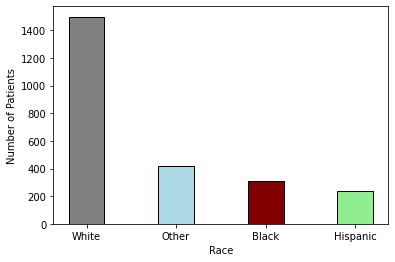

In [87]:
# Plot distribution of patients by Smoke Status
plt.bar(['White', 'Other', 'Black', 'Hispanic'], features[zeta == 0].Race.value_counts(), color = ['grey', 'lightblue', 'maroon', 'lightgreen'],
        width = 0.4, edgecolor='black')
plt.xlabel("Race")
plt.ylabel("Number of Patients")
plt.savefig("ACCORD race harmed.pdf", format='pdf', bbox_inches='tight')
# plt.title("Distribution of Patients in Zeta 0 by Smoke Status at Baseline")
plt.show()

In [9]:
(zeta == 0).sum()

2460

In [10]:
(zeta == 1).sum()

2818

In [11]:
outcomes[zeta == 0].event.sum() / sum(outcomes.event)

0.46723044397463004

In [12]:
outcomes[zeta == 1].event.sum() / sum(outcomes.event)

0.53276955602537

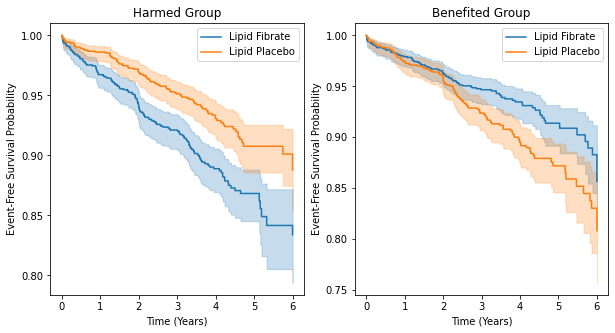

In [14]:
fig, ((ax2, ax1)) = plt.subplots(1, 2, figsize=(10, 5))
reporting.plot_kaplanmeier(outcomes[zeta == 0], intervention[zeta == 0], ax=ax1)
reporting.plot_kaplanmeier(outcomes[zeta == 1], intervention[zeta == 1], ax=ax2)
ax2.set_title('Harmed Group')
ax1.set_title('Benefited Group')
for ax in fig.get_axes():
    # ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Years)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['Lipid Fibrate', 'Lipid Placebo'], loc="upper right")
plt.savefig("ACCORD phe.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [10]:
hr = treatment_effect('hazard_ratio', outcomes, intervention=='Lipid Fibrate', n_bootstrap=100)
CI = np.quantile(hr, [0.025, 0.975])
print(CI)
print(sum(hr)/len(hr))

c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\metrics.py:107: UserWarning: WARNING: You are computing Hazard Ratios.
 Make sure you have tested the PH Assumptions.
  warnings.warn("WARNING: You are computing Hazard Ratios.\n Make sure you have tested the PH Assumptions.")


Bootstrapping...  100  number of times. This may take a while. Please be Patient...
[0.90946731 1.30464757]
1.0836585019025158


In [11]:
hr_zeta0 = treatment_effect('hazard_ratio', outcomes[zeta == 0], intervention[zeta == 0] == 'Lipid Fibrate', n_bootstrap=100)
CI_zeta0 = np.quantile(hr_zeta0, [0.025, 0.975])
print(CI_zeta0)
print(sum(hr_zeta0)/len(hr_zeta0))

c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\metrics.py:107: UserWarning: WARNING: You are computing Hazard Ratios.
 Make sure you have tested the PH Assumptions.
  warnings.warn("WARNING: You are computing Hazard Ratios.\n Make sure you have tested the PH Assumptions.")


Bootstrapping...  100  number of times. This may take a while. Please be Patient...
[1.28401216 2.12674127]
1.673591666627116


In [12]:
hr_zeta1 = treatment_effect('hazard_ratio', outcomes[zeta == 1], intervention[zeta == 1] == 'Lipid Fibrate', n_bootstrap=100)
CI_zeta1 = np.quantile(hr_zeta1, [0.025, 0.975])
print(CI_zeta1)
print(sum(hr_zeta1)/len(hr_zeta1))

c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\metrics.py:107: UserWarning: WARNING: You are computing Hazard Ratios.
 Make sure you have tested the PH Assumptions.
  warnings.warn("WARNING: You are computing Hazard Ratios.\n Make sure you have tested the PH Assumptions.")


Bootstrapping...  100  number of times. This may take a while. Please be Patient...
[0.55666256 0.91088539]
0.7350877517799659


In [17]:
# Get the numerical features
cols_to_use2 = features.columns.difference(features_prep.columns)
feat_num = features.loc[:, ~features.columns.isin(cols_to_use2)]
feat_num

,Baseline_Alanine_Transaminase,Baseline_Estimated_Glomerular_Filtration_Rate,Baseline_Heart_Rate,Baseline_Urine_albumin,Baseline_Total_Cholesterol,Baseline_Urine_creatinine,Baseline_Seated_Diastolic_Blood_Pressure,Baseline_Triglycerides,Baseline_Urine_albumin/creatinine_ratio,Baseline_LDL_Cholesterol,Baseline_HDL_Cholesterol,Baseline_Age,Baseline_Creatine_Phosphokinase,Baseline_Seated_Systolic_Blood_Pressure,Baseline_Fasting_Plasma_Glucose,Baseline_Very_low_density_lipoprotein,Baseline_Potassium,Baseline_Serum_creatinine
MaskID,,,,,,,,,,,,,,,,,,
109052.0,27.0,76.8,81.0,0.41,237.0,0.586,84.0,199.0,0.7,156.0,41.0,63.7,83.0,122.0,228.0,40.0,4.66,0.8
100041.0,25.0,65.2,85.0,117.00,193.0,0.648,72.0,179.0,180.6,126.0,31.0,62.2,221.0,124.0,139.0,36.0,4.51,1.2
108663.0,30.0,92.0,NaN,0.47,186.0,0.457,NaN,158.0,1.0,126.0,28.0,58.5,56.0,NaN,157.0,32.0,3.96,0.9
106707.0,83.0,101.9,69.0,3.99,196.0,1.091,94.0,227.0,3.7,123.0,28.0,68.8,610.0,171.0,166.0,45.0,4.35,0.8
103485.0,32.0,110.1,97.0,1.19,194.0,1.475,94.0,232.0,0.8,111.0,37.0,55.6,74.0,126.0,169.0,46.0,4.89,0.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109656.0,27.0,70.2,49.0,0.68,152.0,1.708,71.0,177.0,0.4,60.0,57.0,69.7,191.0,133.0,106.0,35.0,4.30,1.3
106228.0,22.0,72.9,52.0,58.30,159.0,0.694,66.0,241.0,84.0,76.0,35.0,58.7,207.0,135.0,200.0,48.0,5.18,1.1
103059.0,29.0,124.2,59.0,0.37,149.0,1.312,81.0,117.0,0.3,84.0,42.0,55.6,58.0,138.0,126.0,23.0,4.36,0.7


In [18]:
# Get the categorical features
cols_to_use = features_prep.columns.difference(features.columns)
feat_cat = features_prep[cols_to_use]
feat_cat

,Baseline_BMI_>32_Yes,Baseline_History_Albuminuria_Not Available,Baseline_History_Albuminuria_Yes,Baseline_History_Angina_Yes,Baseline_History_Cardiovascular_Disease_Yes,Baseline_History_Coronary_Artery_Bypass_Graft_Yes,Baseline_History_Left_Ventricular_Hypertrophy_Not Available,Baseline_History_Left_Ventricular_Hypertrophy_Yes,Baseline_History_Myocardial_Infarction_Yes,Baseline_History_Percutaneous_Coronary_Intervention_Yes,...,Baseline_Low_Ankle_Brachial_Index_Not Available,Baseline_Low_Ankle_Brachial_Index_Yes,Baseline_Not_On_Blood_Pressure_Medication_Yes,Baseline_On_Blood_Pressure_Medication_Yes,Baseline_Prior_revascularization_Yes,Baseline_Smoke_status_Yes,Race_Hispanic,Race_Other,Race_White,Sex_Male
MaskID,,,,,,,,,,,,,,,,,,,,,
109052.0,1,1,0,0,0,0,1,0,0,0,...,1,0,0,1,0,0,0,0,1,0
100041.0,0,0,1,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,1
108663.0,0,1,0,0,0,0,1,0,0,0,...,1,0,0,1,0,0,0,1,0,1
106707.0,0,0,1,0,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,1,1
103485.0,1,0,0,0,0,0,0,0,0,0,...,1,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109656.0,0,0,0,0,0,0,1,0,0,0,...,1,0,0,1,0,0,0,0,0,1
106228.0,1,0,1,0,1,0,1,0,0,1,...,1,0,0,1,0,0,0,0,1,1
103059.0,0,0,0,0,0,0,1,0,0,0,...,1,0,0,1,0,0,0,0,1,1


In [19]:
# Get the features to train Decision Tree Classifier
features_dt = pd.merge(feat_cat, feat_num, left_index=True, right_index=True, how='inner')
features_dt

,Baseline_BMI_>32_Yes,Baseline_History_Albuminuria_Not Available,Baseline_History_Albuminuria_Yes,Baseline_History_Angina_Yes,Baseline_History_Cardiovascular_Disease_Yes,Baseline_History_Coronary_Artery_Bypass_Graft_Yes,Baseline_History_Left_Ventricular_Hypertrophy_Not Available,Baseline_History_Left_Ventricular_Hypertrophy_Yes,Baseline_History_Myocardial_Infarction_Yes,Baseline_History_Percutaneous_Coronary_Intervention_Yes,...,Baseline_Urine_albumin/creatinine_ratio,Baseline_LDL_Cholesterol,Baseline_HDL_Cholesterol,Baseline_Age,Baseline_Creatine_Phosphokinase,Baseline_Seated_Systolic_Blood_Pressure,Baseline_Fasting_Plasma_Glucose,Baseline_Very_low_density_lipoprotein,Baseline_Potassium,Baseline_Serum_creatinine
MaskID,,,,,,,,,,,,,,,,,,,,,
109052.0,1,1,0,0,0,0,1,0,0,0,...,0.7,156.0,41.0,63.7,83.0,122.0,228.0,40.0,4.66,0.8
100041.0,0,0,1,0,0,0,0,0,0,0,...,180.6,126.0,31.0,62.2,221.0,124.0,139.0,36.0,4.51,1.2
108663.0,0,1,0,0,0,0,1,0,0,0,...,1.0,126.0,28.0,58.5,56.0,NaN,157.0,32.0,3.96,0.9
106707.0,0,0,1,0,0,0,0,0,0,0,...,3.7,123.0,28.0,68.8,610.0,171.0,166.0,45.0,4.35,0.8
103485.0,1,0,0,0,0,0,0,0,0,0,...,0.8,111.0,37.0,55.6,74.0,126.0,169.0,46.0,4.89,0.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109656.0,0,0,0,0,0,0,1,0,0,0,...,0.4,60.0,57.0,69.7,191.0,133.0,106.0,35.0,4.30,1.3
106228.0,1,0,1,0,1,0,1,0,0,1,...,84.0,76.0,35.0,58.7,207.0,135.0,200.0,48.0,5.18,1.1
103059.0,0,0,0,0,0,0,1,0,0,0,...,0.3,84.0,42.0,55.6,58.0,138.0,126.0,23.0,4.36,0.7


In [20]:
from sklearn.model_selection import train_test_split

# Split the SPRINT data into training, validation, and test data
x_train, x_test, y_train, y_test = train_test_split(features_dt, outcomes, test_size=0.3, random_state=1, 
                                          stratify = outcomes.event + 2*(intervention=='Lipid Fibrate'))

print(f'Number of training data points: {len(x_train)}')
print(f'Number of test data points: {len(x_test)}')

Number of training data points: 3694
Number of test data points: 1584


In [21]:
# Get the Zeta for Train data
idxs = x_train.dropna(axis=0).index.values.astype(int)
f_idxs = features_prep.index.values.astype(int)
mask = np.in1d(f_idxs, idxs)

# Get the Zeta for Test data
idxs2 = x_test.dropna(axis=0).index.values.astype(int)
f_idxs2 = features_prep.index.values.astype(int)
mask2 = np.in1d(f_idxs2, idxs2)

In [22]:
from sklearn import tree # Import the decision tree namespace
from sklearn.metrics import plot_confusion_matrix # Generate a confusion matrix

In [29]:
# Create and fit the model using entropy separation and a maximum depth
# Drop NaNs because the feature columns not preprocessed i.e. 
# Numerical features have NaNs 
dt_model = tree.DecisionTreeClassifier(criterion='entropy', max_depth=3)
dt_model.fit(x_train.dropna(axis=0), zeta[mask])

DecisionTreeClassifier(criterion='entropy', max_depth=3)

c:\Users\ASUS\anaconda3\envs\Pandas\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


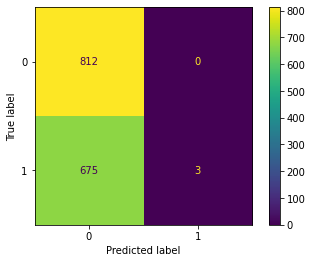

In [30]:
# Plot the confusion matrix
plot_confusion_matrix(dt_model, x_test.dropna(axis = 0), zeta[mask2], values_format='d', labels=[0, 1])

In [31]:
# Get the accuracy of test and train data
from sklearn.model_selection import cross_validate
scoring = ['accuracy','precision', 'recall', 'f1']
scores = cross_validate(dt_model, x_train.dropna(axis = 0), zeta[mask], scoring=scoring, return_train_score=True, cv=5)
results = pd.DataFrame(scores)
results.mean()

fit_time           0.015401
score_time         0.005802
test_accuracy      0.530520
train_accuracy     0.550156
test_precision     0.550745
train_precision    0.785186
test_recall        0.084663
train_recall       0.105374
test_f1            0.120845
train_f1           0.154583
dtype: float64

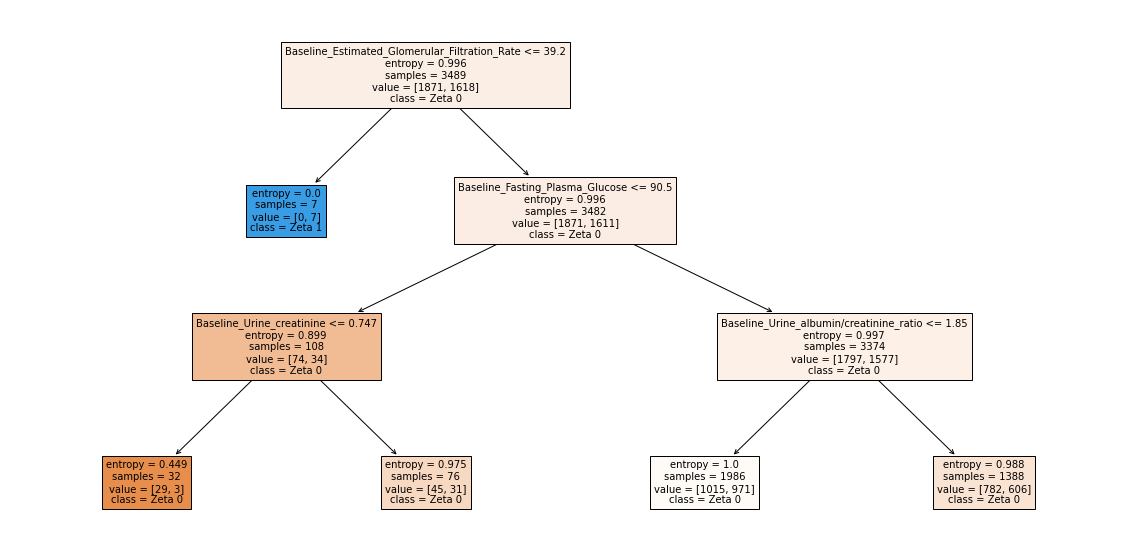

In [33]:
# Let's check out the tree
plt.figure(figsize=(20,10))
tree.plot_tree(dt_model, feature_names=features_dt.columns, class_names=['Zeta 0', 'Zeta 1'], fontsize=10, filled=True)
plt.show()